In [ ]:
%load_ext autoreload
%autoreload 2

# SCF1 vs SCF8

RoPE-scaling correctness check: old (scf8-trained, scf1-inferred -- mismatched) vs fixed (scf8/scf8) vs current (scf1/scf1, where retrained). Not every model was retrained at scf1 yet (e.g. off-by-one sink), so the current group only has full/gated/sink.

In [ ]:
import os
import sys
import matplotlib.pyplot as plt

PDM_DIR = os.environ.get('PDM_DIR', '../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid, load_long_fineweb_inference_nll_grid
from attn_bench.plotting.long_inference import plot_loss_panel
from attn_bench.plotting.heatmap import plot_models_heatmap_panel
from attn_bench.plotting.utils import SEQ_LEN

## Load memorization results

In [2]:
old_models = ['full-scf8-scf1', 'full-xdl-scf8-scf1', 'full-80B-scf8-scf1', 'full-long-docs-scf8-scf1', 'full-short-docs-scf8-scf1', 'full-goldfish-scf8-scf1',
              'gated-scf8-scf1',
              'learn-sink-scf8-scf1', 'off-by-one-scf8-scf1',
              'gdn', 'gdn-xdl', 'gdn-xdl-xsl-0.5', 'gdn-xdl-xsl', 'gdn-goldfish',
              ]
new_models = ['full-scf8', 'full-xdl-scf8', 'full-80B-scf8', 'full-long-docs-scf8', 'full-short-docs-scf8', 'full-goldfish-scf8',
              'gated-scf8',
              'learn-sink-scf8', 'off-by-one-scf8',
              'gdn', 'gdn-xdl', 'gdn-xdl-xsl-0.5', 'gdn-xdl-xsl', 'gdn-goldfish',
              ]
current_models = ['full-scf1', 'gated-scf1', 'sink-scf1']  # only families actually retrained at scf1 so far
MODELS = old_models + new_models + current_models

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000, 3000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

## Rouge-L

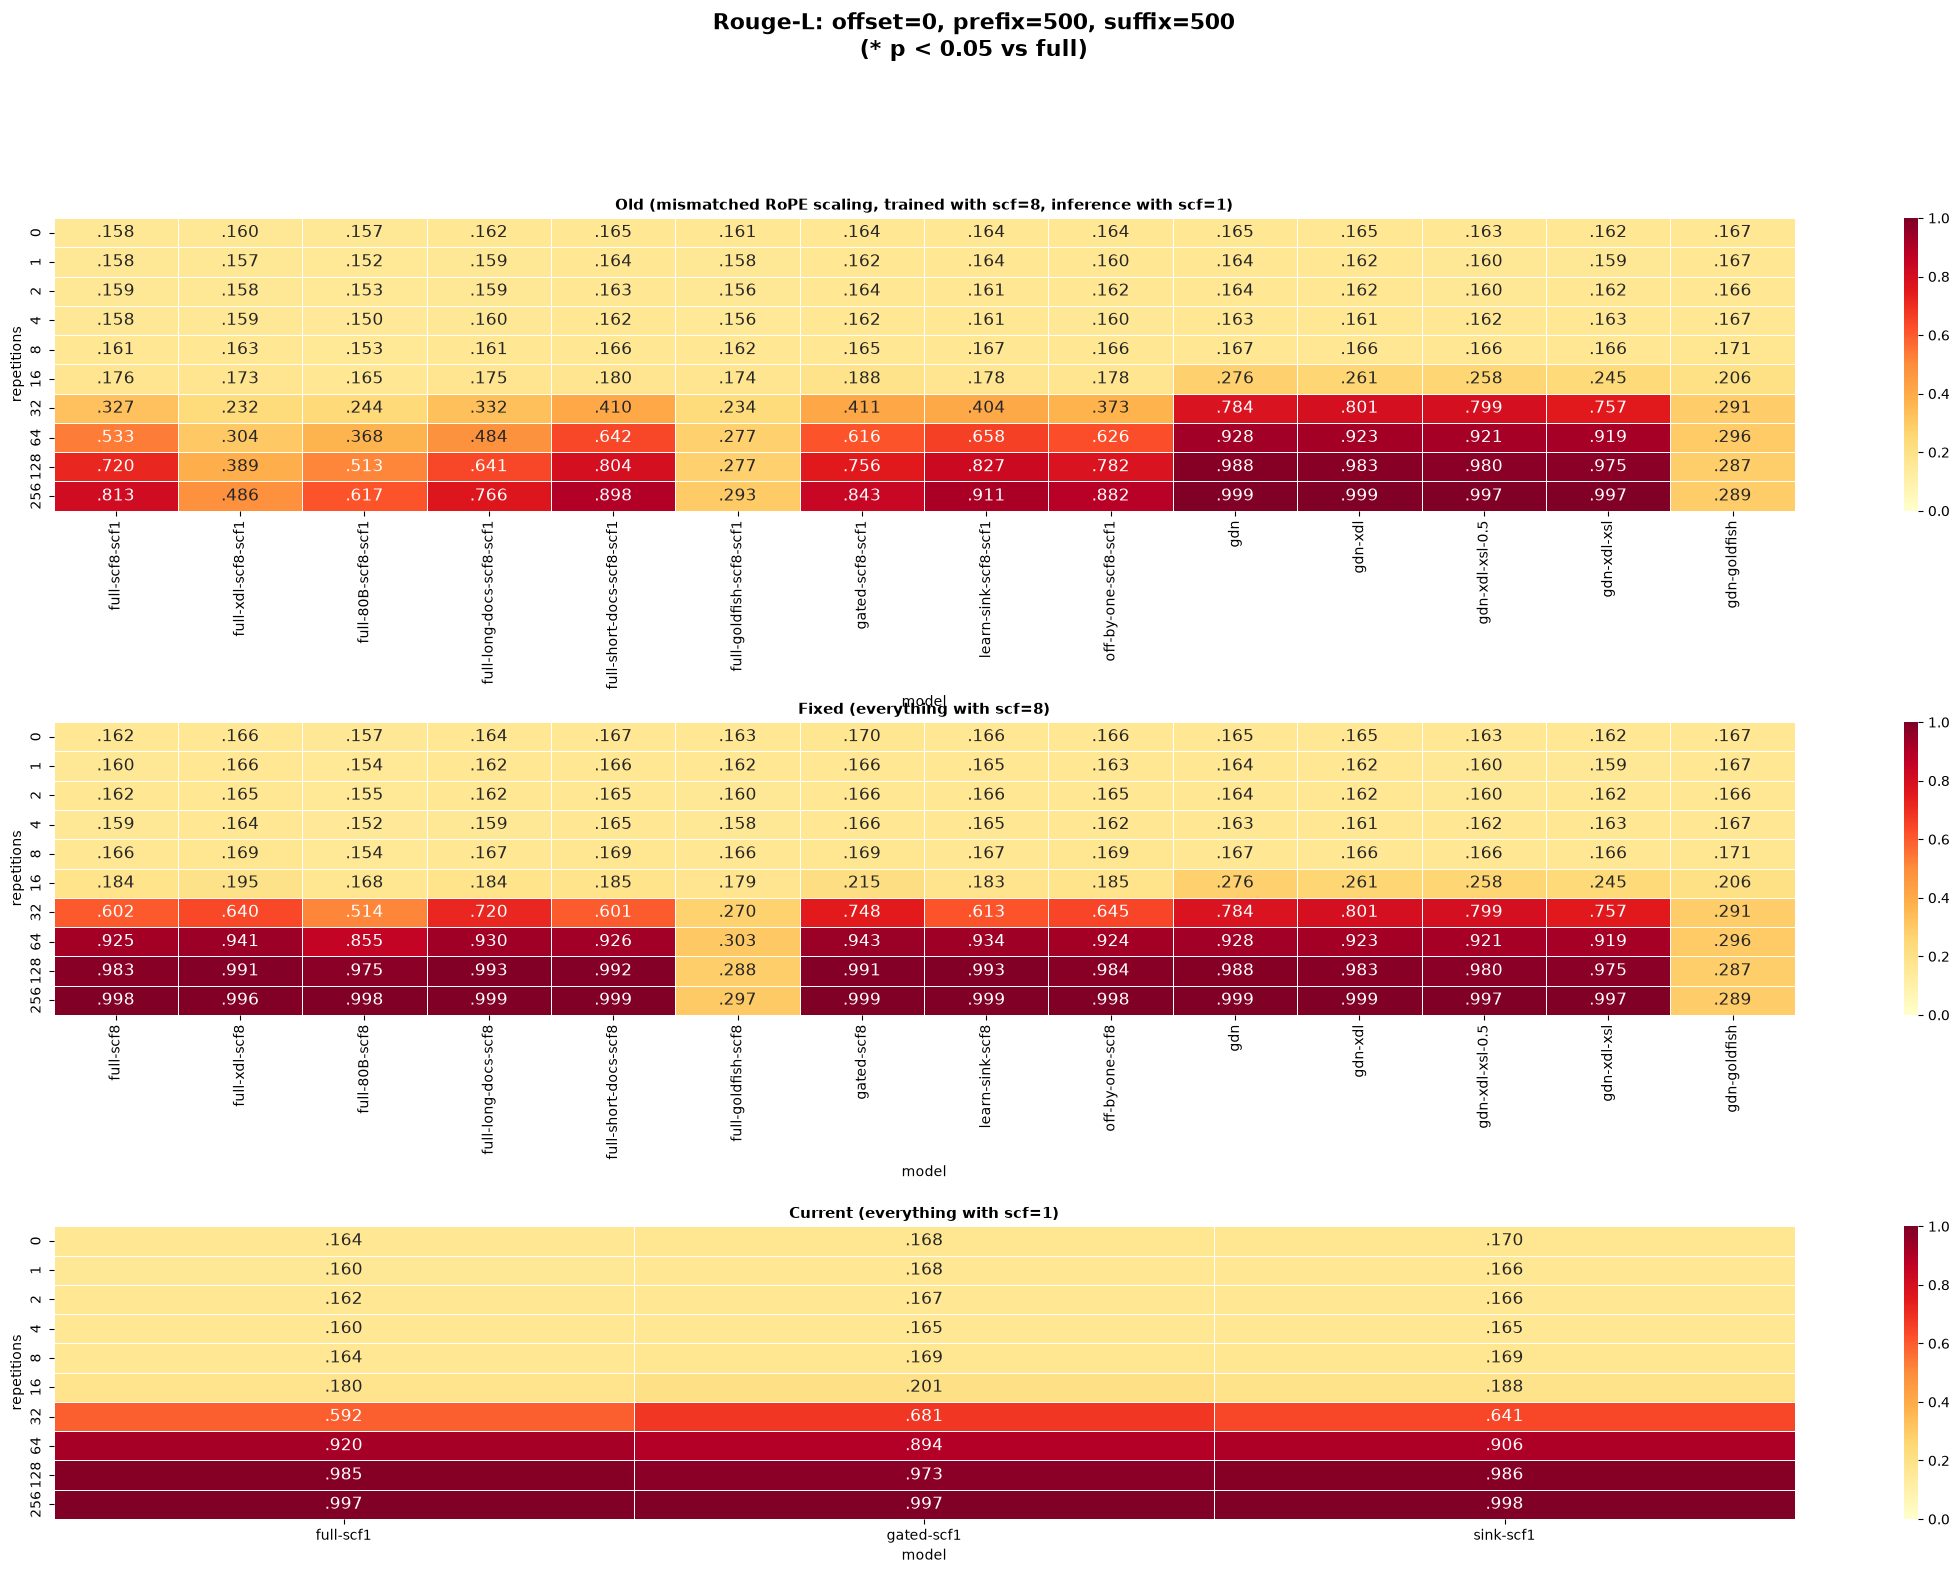

In [3]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', panels='models',
    values=[('Old (mismatched RoPE scaling, trained with scf=8, inference with scf=1)', old_models),
            ('Fixed (everything with scf=8)', new_models),
            ('Current (everything with scf=1)', current_models)],
    fixed_offset=0, fixed_prefix=500, fixed_suffix=500, ncols=1, show_pvalues=False,
)

## Behavioral: long FineWeb-Edu, seen only

`*-scf8` reruns fix a bug where RoPE scaling was silently disabled at inference despite being on
during training (`--use-checkpoint-args` left it at its `False` default). See `long_inference.ipynb`
for the full model sweep; only full/full-xdl/full-long-docs/full-short-docs have long-inference
data for both old and scf8 generations.

Caveat: only `full`/`full-xdl` have a genuine seen/unseen split -- `full-long-docs`/`full-short-docs`
saw the whole corpus regardless of partition (since it's on long docs).

In [4]:
BASE_MODELS = ["full", "full-xdl", "full-long-docs", "full-short-docs"]
# rename_scf8_results.sh (da76e69e1) superseded the original -scf-8 naming below with
# -scf8 (fixed) / -scf8-scf1 (old, archived under this name) -- the -scf-8 folders and the
# bare pre-rename names are both gone now.
OLD_MODELS = [f"{m}-scf8-scf1" for m in BASE_MODELS]
MODELS_TO_PLOT = [f"{m}-scf8" for m in BASE_MODELS]

# Same colors as long_inference_individual.ipynb's BUMP_MODEL_COLORS, keyed to the -scf8
# model names -- so the same model reads as the same color across both notebooks.
BUMP_MODEL_COLORS_SCF8 = {
    "full-scf8": "#0072B2",
    "full-xdl-scf8": "#E69F00",
    "full-long-docs-scf8": "#009E73",
    "full-short-docs-scf8": "#CC79A7",
}

### Seen FineWeb-Edu: scf-8 rerun vs old

Color = model (same hue old vs scf-8), linestyle = rerun (dotted = old/pre-fix, solid = scf-8).

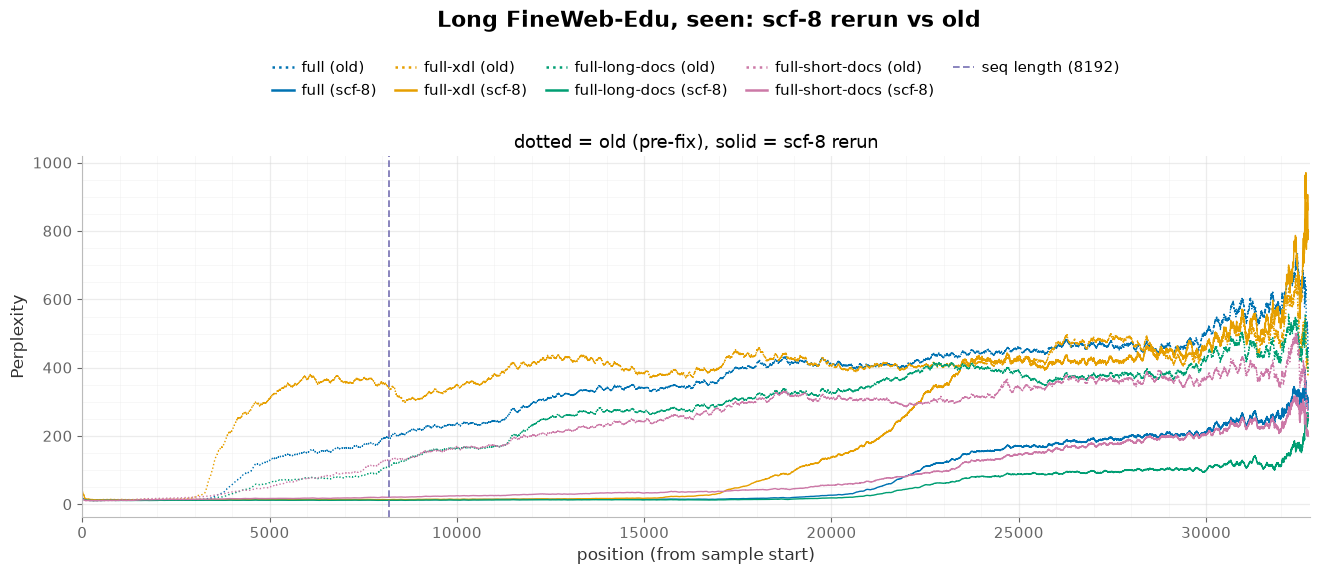

In [5]:
old_fineweb_grid = load_long_fineweb_inference_nll_grid(partitions=("seen",), models=OLD_MODELS)
scf8_fineweb_grid = load_long_fineweb_inference_nll_grid(partitions=("seen",), models=MODELS_TO_PLOT)

fineweb_compare_colors, fineweb_compare_styles, fineweb_compare_grid = {}, {}, {}
for base in BASE_MODELS:
    old, scf8 = f"{base}-scf8-scf1", f"{base}-scf8"
    if old in old_fineweb_grid and "seen" in old_fineweb_grid[old]:
        lab = f"{base} (old)"
        fineweb_compare_grid[lab] = {"seen": old_fineweb_grid[old]["seen"]}
        fineweb_compare_colors[lab] = BUMP_MODEL_COLORS_SCF8[scf8]
        fineweb_compare_styles[lab] = ":"
    if scf8 in scf8_fineweb_grid and "seen" in scf8_fineweb_grid[scf8]:
        lab = f"{base} (scf-8)"
        fineweb_compare_grid[lab] = {"seen": scf8_fineweb_grid[scf8]["seen"]}
        fineweb_compare_colors[lab] = BUMP_MODEL_COLORS_SCF8[scf8]
        fineweb_compare_styles[lab] = "-"

fig = plot_loss_panel(fineweb_compare_grid, ncols=1, cell_w=14, metric="ppl", show_random_baseline=False,
                      smooth_window=100, xmax=4 * SEQ_LEN,
                      show_std=False, show_count=False, sharey=True,
                      colors=fineweb_compare_colors, linestyles=fineweb_compare_styles,
                      bucket_title_fn=lambda b: "dotted = old (pre-fix), solid = scf-8 rerun",
                      suptitle="Long FineWeb-Edu, seen: scf-8 rerun vs old",
                      vlines={"seq length": SEQ_LEN})
plt.show()

### Seen FineWeb-Edu: scf-8 rerun only

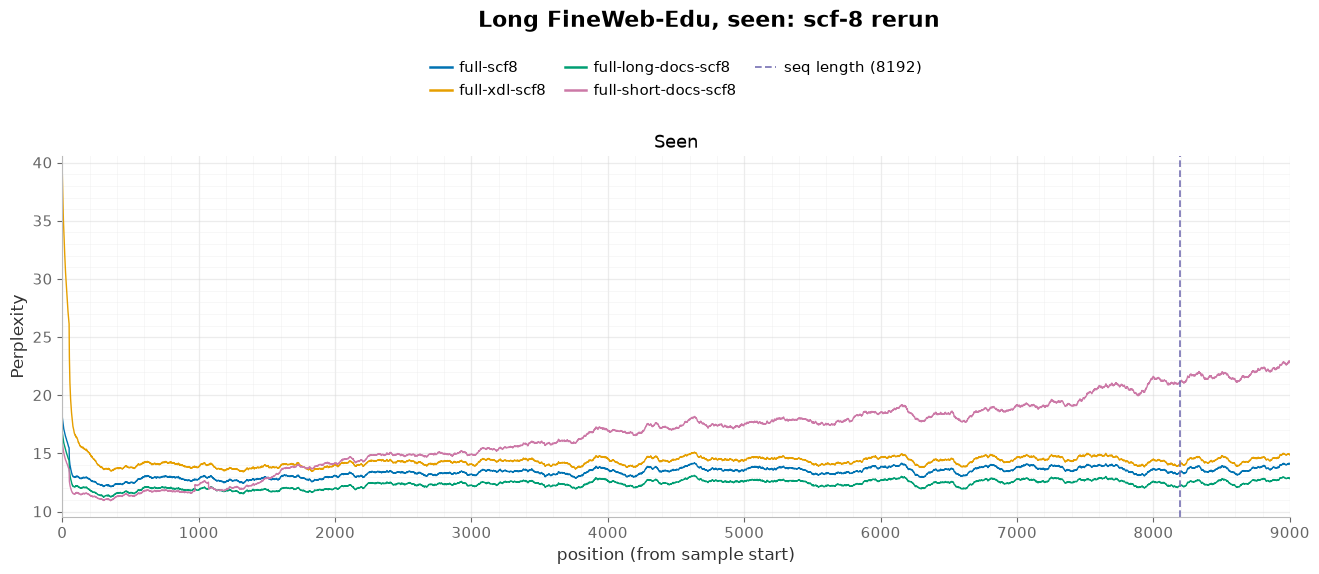

In [6]:
fig = plot_loss_panel(scf8_fineweb_grid, ncols=1, cell_w=14, metric="ppl", show_random_baseline=False,
                      smooth_window=100, xmax=9000,
                      show_std=False, show_count=False, sharey=True,
                      colors=BUMP_MODEL_COLORS_SCF8,
                      bucket_title_fn=str.capitalize,
                      suptitle="Long FineWeb-Edu, seen: scf-8 rerun",
                      vlines={"seq length": SEQ_LEN})
plt.show()